In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
Jaccard_df <- read.csv("03A_non_binarized_disease_Jaccard.csv")

In [3]:
cell_types <- unique(Jaccard_df$cell_type)
directions <- unique(Jaccard_df$direction)
diseases <- c("ICM", "DCM", "HCM")

diagonal_rows <- expand_grid(
  cell_type = cell_types,
  direction = directions,
  disease1 = diseases,
  disease2 = diseases
) %>%
  filter(disease1 == disease2) %>%
  mutate(jaccard = 1)

# bind with original df
Jaccard_df_complete <- bind_rows(Jaccard_df, diagonal_rows)

Saving 7 x 7 in image


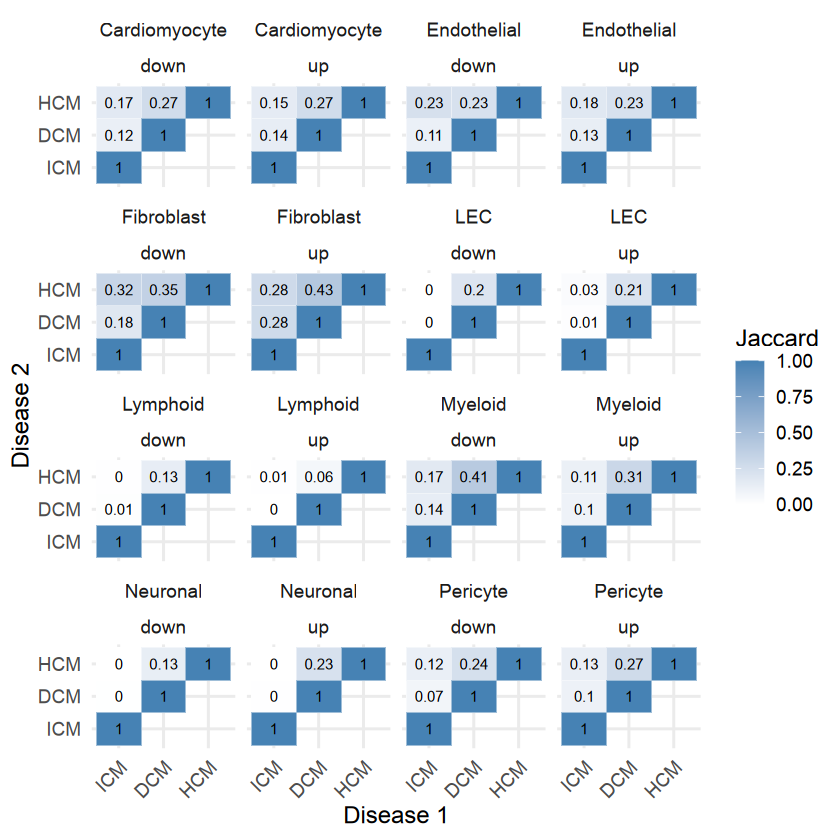

In [5]:
options(repr.plot.width = 7, repr.plot.height = 7)

Jaccard_df_complete$disease1 <- factor(Jaccard_df_complete$disease1, levels = c("ICM", "DCM", "HCM"))
Jaccard_df_complete$disease2 <- factor(Jaccard_df_complete$disease2, levels = c("ICM", "DCM", "HCM"))

p2 <- ggplot(Jaccard_df_complete, aes(x = disease1, y = disease2, fill = jaccard)) +
  geom_tile(color = "white") +
  geom_text(aes(label = round(jaccard, 2)), color = "black", size = 3) +  # show values
  scale_fill_gradient(low = "white", high = "steelblue") +
  facet_wrap(~ cell_type + direction) +
  labs(x = "Disease 1", y = "Disease 2", fill = "Jaccard") +
  theme_minimal(base_size = 14) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

ggsave(p2, filename="03B_disease_Jaccard_similarility.pdf")

p2